# DBSCAN pada Dataset URL

Notebook ini menggunakan preprocessing dari `Untitled2.ipynb` sampai `StandardScaler`: membaca dataset, memisahkan `url` dan `status`, mengambil fitur numerik, mengisi nilai kosong dengan median, dan menghapus fitur konstan. Sel kode preprocessing disalin persis dari notebook sumber.

Kedua notebook menggunakan seluruh data tanpa sampling, urutan baris, fitur, scaler, `eps=0.5`, `min_samples=5`, metode pencarian tetangga, evaluasi, dan visualisasi yang sama. Satu-satunya perbedaan kode adalah nilai `DISTANCE_METRIC`: `"euclidean"` atau `"cosine"`.

DBSCAN menerima **jarak**. Untuk cosine, jarak = `1 - cosine similarity`; pada `eps=0.5`, tetangga memenuhi cosine similarity ≥ 0.5. Nilai `eps` dibuat sama untuk mengisolasi perubahan metrik, walaupun skala kedua jarak berbeda. Parameter ini belum dioptimalkan untuk masing-masing metrik.

Kolom `status` disimpan sebagai label asli dan tidak digunakan untuk membentuk cluster. PCA hanya dipakai untuk visualisasi setelah clustering; DBSCAN menggunakan semua fitur pada `X_scaled`.

Dokumentasi: [DBSCAN](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.DBSCAN.html), [cosine distance](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.pairwise.cosine_distances.html), dan [silhouette score](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.silhouette_score.html).


## Langkah 1: Import Library

In [99]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.feature_selection import VarianceThreshold

## Langkah 2: Membaca Dataset

In [100]:
FILE = "dataset_B_05_2020 (1).csv"

df = pd.read_csv(FILE)

print("Shape dataset:", df.shape)
print("Jumlah data:", df.shape[0])
print("Jumlah kolom:", df.shape[1])

Shape dataset: (11430, 89)
Jumlah data: 11430
Jumlah kolom: 89


## Langkah 3: Mengambil Fitur Numerik

In [101]:
urls = df["url"].copy()
labels = df["status"].copy()

# Hanya fitur numerik
X = df.drop(columns=["url", "status"])
X = X.select_dtypes(include=np.number)

print("\nShape fitur numerik:", X.shape)
df.head()


Shape fitur numerik: (11430, 87)


,url,length_url,length_hostname,ip,nb_dots,nb_hyphens,nb_at,nb_qm,nb_and,nb_or,...,domain_in_title,domain_with_copyright,whois_registered_domain,domain_registration_length,domain_age,web_traffic,dns_record,google_index,page_rank,status
0,http://www.crestonwood.com/router.php,37,19,0,3,0,0,0,0,0,...,0,1,0,45,-1,0,1,1,4,legitimate
1,http://shadetreetechnology.com/V4/validation/a...,77,23,1,1,0,0,0,0,0,...,1,0,0,77,5767,0,0,1,2,phishing
2,https://support-appleld.com.secureupdate.duila...,126,50,1,4,1,0,1,2,0,...,1,0,0,14,4004,5828815,0,1,0,phishing
3,http://rgipt.ac.in,18,11,0,2,0,0,0,0,0,...,1,0,0,62,-1,107721,0,0,3,legitimate
4,http://www.iracing.com/tracks/gateway-motorspo...,55,15,0,2,2,0,0,0,0,...,0,1,0,224,8175,8725,0,0,6,legitimate


## Langkah 4: Menangani Missing Value

In [102]:

print("Total missing value:", X.isna().sum().sum())

X = X.fillna(X.median())


Total missing value: 0


## Langkah 5: Menghapus Fitur Konstan

In [103]:
selector = VarianceThreshold(threshold=0)

X_selected = selector.fit_transform(X)

selected_features = X.columns[
    selector.get_support()
]

X_selected = pd.DataFrame(
    X_selected,
    columns=selected_features
)

print("\nSetelah menghapus fitur konstan:")
print("Shape:", X_selected.shape)

print("Jumlah fitur:", len(selected_features))



Setelah menghapus fitur konstan:
Shape: (11430, 81)
Jumlah fitur: 81


## Langkah 6: StandardScaler

In [104]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X_selected)

print("\nSetelah StandardScaler:")
print("Shape:", X_scaled.shape)
df.head()


Setelah StandardScaler:
Shape: (11430, 81)


,url,length_url,length_hostname,ip,nb_dots,nb_hyphens,nb_at,nb_qm,nb_and,nb_or,...,domain_in_title,domain_with_copyright,whois_registered_domain,domain_registration_length,domain_age,web_traffic,dns_record,google_index,page_rank,status
0,http://www.crestonwood.com/router.php,37,19,0,3,0,0,0,0,0,...,0,1,0,45,-1,0,1,1,4,legitimate
1,http://shadetreetechnology.com/V4/validation/a...,77,23,1,1,0,0,0,0,0,...,1,0,0,77,5767,0,0,1,2,phishing
2,https://support-appleld.com.secureupdate.duila...,126,50,1,4,1,0,1,2,0,...,1,0,0,14,4004,5828815,0,1,0,phishing
3,http://rgipt.ac.in,18,11,0,2,0,0,0,0,0,...,1,0,0,62,-1,107721,0,0,3,legitimate
4,http://www.iracing.com/tracks/gateway-motorspo...,55,15,0,2,2,0,0,0,0,...,0,1,0,224,8175,8725,0,0,6,legitimate


## Langkah 7: Parameter DBSCAN

In [105]:
import matplotlib.pyplot as plt

from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score

# Ubah hanya baris ini pada notebook pasangan.
DISTANCE_METRIC = "cosine"

EPS = 0.5
MIN_SAMPLES = 5
RANDOM_STATE = 42

print("Metrik jarak:", DISTANCE_METRIC)
print("eps:", EPS)
print("min_samples:", MIN_SAMPLES)

Metrik jarak: cosine
eps: 0.7
min_samples: 20


## Langkah 8: Menjalankan DBSCAN

In [106]:
dbscan = DBSCAN(
    eps=EPS,
    min_samples=MIN_SAMPLES,
    metric=DISTANCE_METRIC,
    algorithm="brute",
    n_jobs=1
)

cluster_labels = dbscan.fit_predict(X_scaled)

print("Jumlah label cluster:", len(cluster_labels))

Jumlah label cluster: 11430


## Langkah 9: Hasil Cluster dan Noise

Label `-1` menunjukkan noise. Core point memenuhi jumlah minimum tetangga; border point masuk cluster tetapi bukan core point.

In [107]:
noise_mask = cluster_labels == -1
core_mask = np.zeros(len(cluster_labels), dtype=bool)
core_mask[dbscan.core_sample_indices_] = True
border_mask = (~noise_mask) & (~core_mask)

n_clusters = len(set(cluster_labels)) - int(noise_mask.any())
n_noise = int(noise_mask.sum())

print("Metrik jarak:", DISTANCE_METRIC)
print("Jumlah cluster (tanpa noise):", n_clusters)
print("Jumlah core point:", int(core_mask.sum()))
print("Jumlah border point:", int(border_mask.sum()))
print("Jumlah noise:", n_noise)
print(f"Persentase noise: {100 * noise_mask.mean():.2f}%")

cluster_counts = (
    pd.Series(cluster_labels, name="Cluster")
    .value_counts()
    .sort_index()
    .rename_axis("Cluster")
    .reset_index(name="Jumlah Data")
)

cluster_counts["Persentase (%)"] = (
    cluster_counts["Jumlah Data"] / len(cluster_labels) * 100
).round(2)

cluster_counts

Metrik jarak: cosine
Jumlah cluster (tanpa noise): 2
Jumlah core point: 11370
Jumlah border point: 32
Jumlah noise: 28
Persentase noise: 0.24%


,Cluster,Jumlah Data,Persentase (%)
0,-1,28,0.24
1,0,11378,99.55
2,1,24,0.21


## Langkah 10: Evaluasi Silhouette

Silhouette dihitung pada **seluruh data non-noise tanpa sampling**, menggunakan fitur yang telah diskalakan dan metrik yang sama dengan DBSCAN. DBSCAN tetap menggunakan seluruh baris dataset, termasuk data yang kemudian diberi label noise. Evaluasi hanya dilakukan jika data non-noise memiliki minimal dua cluster dan jumlah cluster lebih kecil dari jumlah data. Nilai silhouette mengikuti geometri masing-masing metrik.

In [108]:
X_evaluation = X_scaled[~noise_mask]
labels_evaluation = cluster_labels[~noise_mask]
n_evaluation_clusters = len(np.unique(labels_evaluation))

silhouette = None

if 2 <= n_evaluation_clusters < len(labels_evaluation):
    silhouette = silhouette_score(
        X_evaluation,
        labels_evaluation,
        metric=DISTANCE_METRIC
    )
    print("Jumlah data evaluasi (seluruh data non-noise):", len(labels_evaluation))
    print("Jumlah cluster pada data evaluasi:", n_evaluation_clusters)
    print(f"Silhouette score ({DISTANCE_METRIC}): {silhouette:.4f}")
else:
    print("Silhouette tidak dihitung: data evaluasi tidak memenuhi syarat jumlah cluster.")

Jumlah data evaluasi (seluruh data non-noise): 11402
Jumlah cluster pada data evaluasi: 2
Silhouette score (cosine): 0.0098


## Langkah 11: Visualisasi PCA

Koordinat PCA dihitung dari seluruh `X_scaled` dengan pengaturan yang sama pada kedua notebook. Proyeksi dua dimensi ini hanya untuk melihat hasil; jarak DBSCAN tetap dihitung pada semua fitur yang telah diskalakan.

Total explained variance PCA: 15.51%


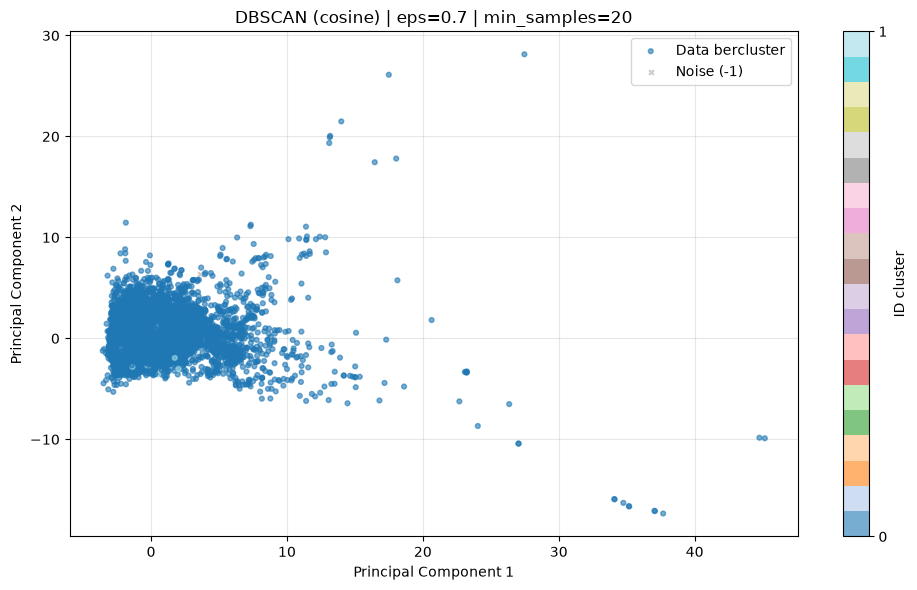

In [109]:
pca = PCA(n_components=2, svd_solver="full", random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)

print(f"Total explained variance PCA: {pca.explained_variance_ratio_.sum():.2%}")

fig, ax = plt.subplots(figsize=(10, 6))

if (~noise_mask).any():
    points = ax.scatter(
        X_pca[~noise_mask, 0],
        X_pca[~noise_mask, 1],
        c=cluster_labels[~noise_mask],
        cmap="tab20",
        s=12,
        alpha=0.6,
        zorder=2,
        label="Data bercluster"
    )
    if n_clusters > 1:
        fig.colorbar(
            points,
            ax=ax,
            label="ID cluster",
            ticks=np.unique(cluster_labels[~noise_mask]) if n_clusters <= 10 else None
        )

if noise_mask.any():
    ax.scatter(
        X_pca[noise_mask, 0],
        X_pca[noise_mask, 1],
        c="gray",
        marker="x",
        s=12,
        alpha=0.4,
        zorder=1,
        label="Noise (-1)"
    )

ax.set_xlabel("Principal Component 1")
ax.set_ylabel("Principal Component 2")
ax.set_title(
    f"DBSCAN ({DISTANCE_METRIC}) | eps={EPS} | min_samples={MIN_SAMPLES}"
)
ax.grid(alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

## Langkah 12: Menampilkan Label Setiap Data

In [112]:
results = pd.DataFrame({
    "url": urls,
    "status_asli": labels,
    "cluster_dbscan": cluster_labels,
    "tipe_titik": np.where(
        noise_mask,
        "noise",
        np.where(core_mask, "core", "border")
    )
})

results.head(10000)

,url,status_asli,cluster_dbscan,tipe_titik
0,http://www.crestonwood.com/router.php,legitimate,0,core
1,http://shadetreetechnology.com/V4/validation/a...,phishing,0,core
2,https://support-appleld.com.secureupdate.duila...,phishing,0,core
3,http://rgipt.ac.in,legitimate,0,core
4,http://www.iracing.com/tracks/gateway-motorspo...,legitimate,0,core
...,...,...,...,...
9995,http://www.jobs.net/jobs/apstemps,legitimate,0,core
9996,https://www.healthcare-economist.com/,legitimate,0,core
9997,https://www.tumblr.com/safe-mode?url=https%3A%...,legitimate,0,core
9998,https://firebasestorage.googleapis.com/v0/b/fs...,phishing,0,core
